# 4. Mô hình học máy truyền thống (scikit-learn)

**Input:** `exps/feature0/`  
**Output:** log thực nghiệm, `exps/feature0/preds/*.npy`, file nộp `submission_*.csv`

BEGIN

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys; sys.path.insert(0, "../../extra")
from config import *
from common import *
from utils import *
display.clear_output()

In [3]:
MEMBER   = "baseline"      # tên/mã thành viên -> file log riêng
NOTEBOOK = "traditional model"
FEATURE_SET = "feature0"
SELECTION   = None   # None = tất cả cột; hoặc "lasso", "gbr_top50"...
seed_everything()

In [4]:
from models import get_traditional_models
x_train, y_train, x_test, test_id = load_feature_set(FEATURE_SET, SELECTION)

[load] feature0: x_train (1460, 289), x_test (1459, 289)


## 4.1. Đánh giá 5-fold CV
Mọi mô hình đều đi qua `make_pipeline()` (median imputer + StandardScaler) và cùng `get_kfold()`.

In [5]:
results = {}
for name, model in get_traditional_models().items():
    scores, oof = evaluate(model, x_train, y_train)
    results[name] = scores
    log_experiment(MEMBER, NOTEBOOK, FEATURE_SET, name, scores, model.get_params(), SELECTION)
    save_preds(FEATURE_SET, f'{MEMBER}_{name}', oof, fit_predict(model, x_train, y_train, x_test))

[log] LR           | feature0/all | CV RMSE = 0.14879 ± 0.04239
[log] Ridge        | feature0/all | CV RMSE = 0.14716 ± 0.04194
[log] Lasso        | feature0/all | CV RMSE = 0.14432 ± 0.04323
[log] RF           | feature0/all | CV RMSE = 0.14457 ± 0.01933
[log] GBR          | feature0/all | CV RMSE = 0.13024 ± 0.02116


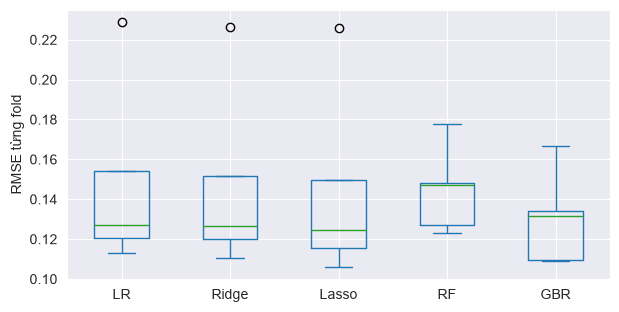

,mean,std
GBR,0.130243,0.023654
Lasso,0.144319,0.048336
RF,0.144569,0.021609
Ridge,0.147160,0.046891
LR,0.148788,0.047388


In [6]:
pd.DataFrame(results).plot.box(figsize=(7, 3.5), ylabel='RMSE từng fold'); plt.show()
pd.DataFrame(results).agg(['mean', 'std']).T.sort_values('mean')

## 4.2. Tạo file nộp cho mô hình tốt nhất

In [7]:
best = min(results, key=lambda k: results[k].mean())
pred = np.load(f'{feature_dir(FEATURE_SET)}/preds/{MEMBER}_{best}_test.npy')
save_submission(FEATURE_SET, f'{MEMBER}_{best}', test_id, pred)

[submit] d:/HocSau/House_Prices/house_prices_project/exps/feature0\submission_baseline_GBR.csv


'd:/HocSau/House_Prices/house_prices_project/exps/feature0\\submission_baseline_GBR.csv'

### Kết luận
- *(ghi nhận xét ở đây)*